Attempting to do linear regression model to predict t90 on only valid storm events (post my filtering)

In [7]:
# CELL 1 — setup, schema check, clean dataset build, configurable target options

import pandas as pd
import numpy as np

# -----------------------
# User-configurable options
# -----------------------
TARGET_NAME = "t90"      # "t90" or "t50"
USE_LOG_TARGET = False   # True or False
STANDARDIZE_NUMERIC = True  # used later in the sklearn pipeline

# Valid-event filter
peak_thresh = 0.15
min_hours_above = 5

# Outage cleaning
med_window = 5
max_short_run = 3
abs_dev_thresh = 0.15
rel_dev_scale = 0.35

# -----------------------
# Paths
# -----------------------
data_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\florida_model_df.parquet"
pous_path = r"C:\Users\teaching\Downloads\outage-recovery-forecasting\data_transients\FL_POUS.csv"

# -----------------------
# Load
# -----------------------
df = pd.read_parquet(data_path)
pous = pd.read_csv(pous_path)

print("Loaded df shape:", df.shape)
print("Loaded POUS shape:", pous.shape)
print("\ndf columns:")
print(df.columns.tolist())

# -----------------------
# Required columns / identifier handling
# -----------------------
needed = ["CountyFIPS", "datetime", "event_start", "duration_hours", "outageFraction",
          "gust_mps", "precip_mm", "pressure_hpa", "temp_c"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in df: {missing}")

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
pous["CountyFIPS"] = pous["CountyFIPS"].astype(str).str.zfill(5)

# Reconstruct event_id only if needed
if "event_id" not in df.columns:
    if {"storm", "event_start"}.issubset(df.columns):
        df["event_id"] = (
            df["storm"].astype(str) + "_" +
            pd.to_datetime(df["event_start"]).astype(str)
        )
        print("\nReconstructed event_id from storm + event_start.")
    else:
        raise KeyError(
            "event_id is missing and cannot be reconstructed. "
            f"Available columns: {df.columns.tolist()}"
        )

df["datetime"] = pd.to_datetime(df["datetime"])
df["event_start"] = pd.to_datetime(df["event_start"])
df = df.sort_values(["event_id", "CountyFIPS", "datetime"]).copy()

group_cols = ["event_id", "CountyFIPS"]

# -----------------------
# 1) Event validity filter
# -----------------------
event_metrics = (
    df.groupby(group_cols, as_index=False)
      .agg(
          max_outage=("outageFraction", "max"),
          hours_above=("outageFraction", lambda s: (s > peak_thresh).sum()),
      )
)

event_metrics["is_valid"] = (
    (event_metrics["max_outage"] >= peak_thresh) &
    (event_metrics["hours_above"] >= min_hours_above)
)

print("\nValid / invalid counts:")
print(event_metrics["is_valid"].value_counts(dropna=False))

valid_pairs = event_metrics.loc[event_metrics["is_valid"], group_cols]
df = df.merge(valid_pairs.assign(_keep=1), on=group_cols, how="inner").drop(columns=["_keep"])

print("\nAfter validity filter:", df.shape)

# -----------------------
# 2) Clean outageFraction
# -----------------------
def clean_outage_group(g):
    g = g.sort_values("datetime").copy()
    s = g["outageFraction"].astype(float).clip(0, 1)

    med = s.rolling(med_window, center=True, min_periods=1).median()
    dev = (s - med).abs()
    thresh = np.maximum(abs_dev_thresh, rel_dev_scale * med)

    anomaly = dev > thresh
    run_id = (anomaly != anomaly.shift()).cumsum()
    run_len = anomaly.groupby(run_id).transform("sum")
    short = anomaly & (run_len <= max_short_run)

    repaired = s.mask(short)
    repaired = repaired.interpolate(limit_direction="both")
    cleaned = repaired.rolling(med_window, center=True, min_periods=1).median()

    g["outage_clean"] = cleaned
    return g

df = (
    df.groupby(group_cols, group_keys=False)
      .apply(clean_outage_group)
      .reset_index(drop=True)
)

# -----------------------
# 3) Target construction
# -----------------------
target_threshold = 0.10 if TARGET_NAME == "t90" else 0.50
target_col = TARGET_NAME

def compute_target(g):
    g = g.sort_values("datetime")
    start = g["event_start"].iloc[0]

    post = g[g["datetime"] >= start].copy()

    below = post[post["outage_clean"] <= target_threshold]

    if len(below) > 0:
        t = (below["datetime"].iloc[0] - start).total_seconds() / 3600.0
        censored = 0
    else:
        t = g["duration_hours"].max()
        censored = 1

    if USE_LOG_TARGET:
        t = np.log1p(t)

    return pd.Series({
        target_col: t,
        "censored": censored,
        "threshold_used": target_threshold
    })

# Reassert grouping keys before target construction
if "event_id" not in df.columns:
    if {"storm", "event_start"}.issubset(df.columns):
        df["event_id"] = df["storm"].astype(str) + "_" + pd.to_datetime(df["event_start"]).astype(str)
    else:
        raise KeyError(f"event_id is missing and cannot be reconstructed. Columns: {df.columns.tolist()}")

# Patch: reconstruct CountyFIPS from geoid
if "CountyFIPS" not in df.columns:
    if "geoid" in df.columns:
        df["CountyFIPS"] = df["geoid"].astype(str).str.zfill(5)
    else:
        raise KeyError(f"CountyFIPS is missing and geoid is unavailable. Columns: {df.columns.tolist()}")

df["CountyFIPS"] = df["CountyFIPS"].astype(str).str.zfill(5)
df["event_id"] = df["event_id"].astype(str)
group_cols = ["event_id", "CountyFIPS"]

targets = (
    df.groupby(group_cols)
      .apply(compute_target)
      .reset_index()
)

print("\nTarget summary:")
print(targets[target_col].describe())
print("Censored fraction:", targets["censored"].mean())

# -----------------------
# 4) Feature construction
# -----------------------
def build_features(g):
    g = g.sort_values("datetime")
    window = g.head(168) if len(g) >= 168 else g

    return pd.Series({
        "max_gust": window["gust_mps"].max(),
        "mean_gust_7d": window["gust_mps"].mean(),
        "total_precip_7d": window["precip_mm"].sum(),
        "pressure_min_7d": window["pressure_hpa"].min(),
    })

features = (
    df.groupby(group_cols)
      .apply(build_features)
      .reset_index()
)

# -----------------------
# 5) County population
# -----------------------
county_pop = (
    pous[["CountyFIPS", "county_pop"]]
    .drop_duplicates()
    .copy()
)

features = features.merge(county_pop, on="CountyFIPS", how="left")

# -----------------------
# 6) Final modelling table
# -----------------------
model_df = features.merge(targets, on=group_cols, how="inner")

print("\nFinal model_df shape:", model_df.shape)
print("\nColumns:")
print(model_df.columns.tolist())
print("\nPreview:")
print(model_df.head().to_string(index=False))

print("\nConfiguration in use:")
print("TARGET_NAME =", TARGET_NAME)
print("USE_LOG_TARGET =", USE_LOG_TARGET)
print("STANDARDIZE_NUMERIC =", STANDARDIZE_NUMERIC)
print("target_threshold =", target_threshold)

Loaded df shape: (17510, 22)
Loaded POUS shape: (99, 13)

df columns:
['event_id', 'storm', 'geoid', 'county', 'datetime', 'event_start', 'duration_hours', 'gust_mps', 'wind_speed_mps', 'precip_mm', 'pressure_hpa', 'temp_c', 'CountyFIPS', 'outageFraction', 'customersTracked', 'persistence_1h', 'error', 'abs_error', 'sq_error', 'persistence_24h', 'persistence_48h', 'persistence_72h']

Valid / invalid counts:
is_valid
True     90
False     9
Name: count, dtype: int64

After validity filter: (16918, 22)

Target summary:
count     90.000000
mean      60.277778
std       95.178723
min        0.000000
25%        0.000000
50%        1.000000
75%      123.750000
max      510.000000
Name: t90, dtype: float64
Censored fraction: 0.0

Final model_df shape: (90, 10)

Columns:
['event_id', 'CountyFIPS', 'max_gust', 'mean_gust_7d', 'total_precip_7d', 'pressure_min_7d', 'county_pop', 't90', 'censored', 'threshold_used']

Preview:
                         event_id CountyFIPS  max_gust  mean_gust_7d  to

the 0hr 25% and 1hr 50% are suspect. Inspect visually.

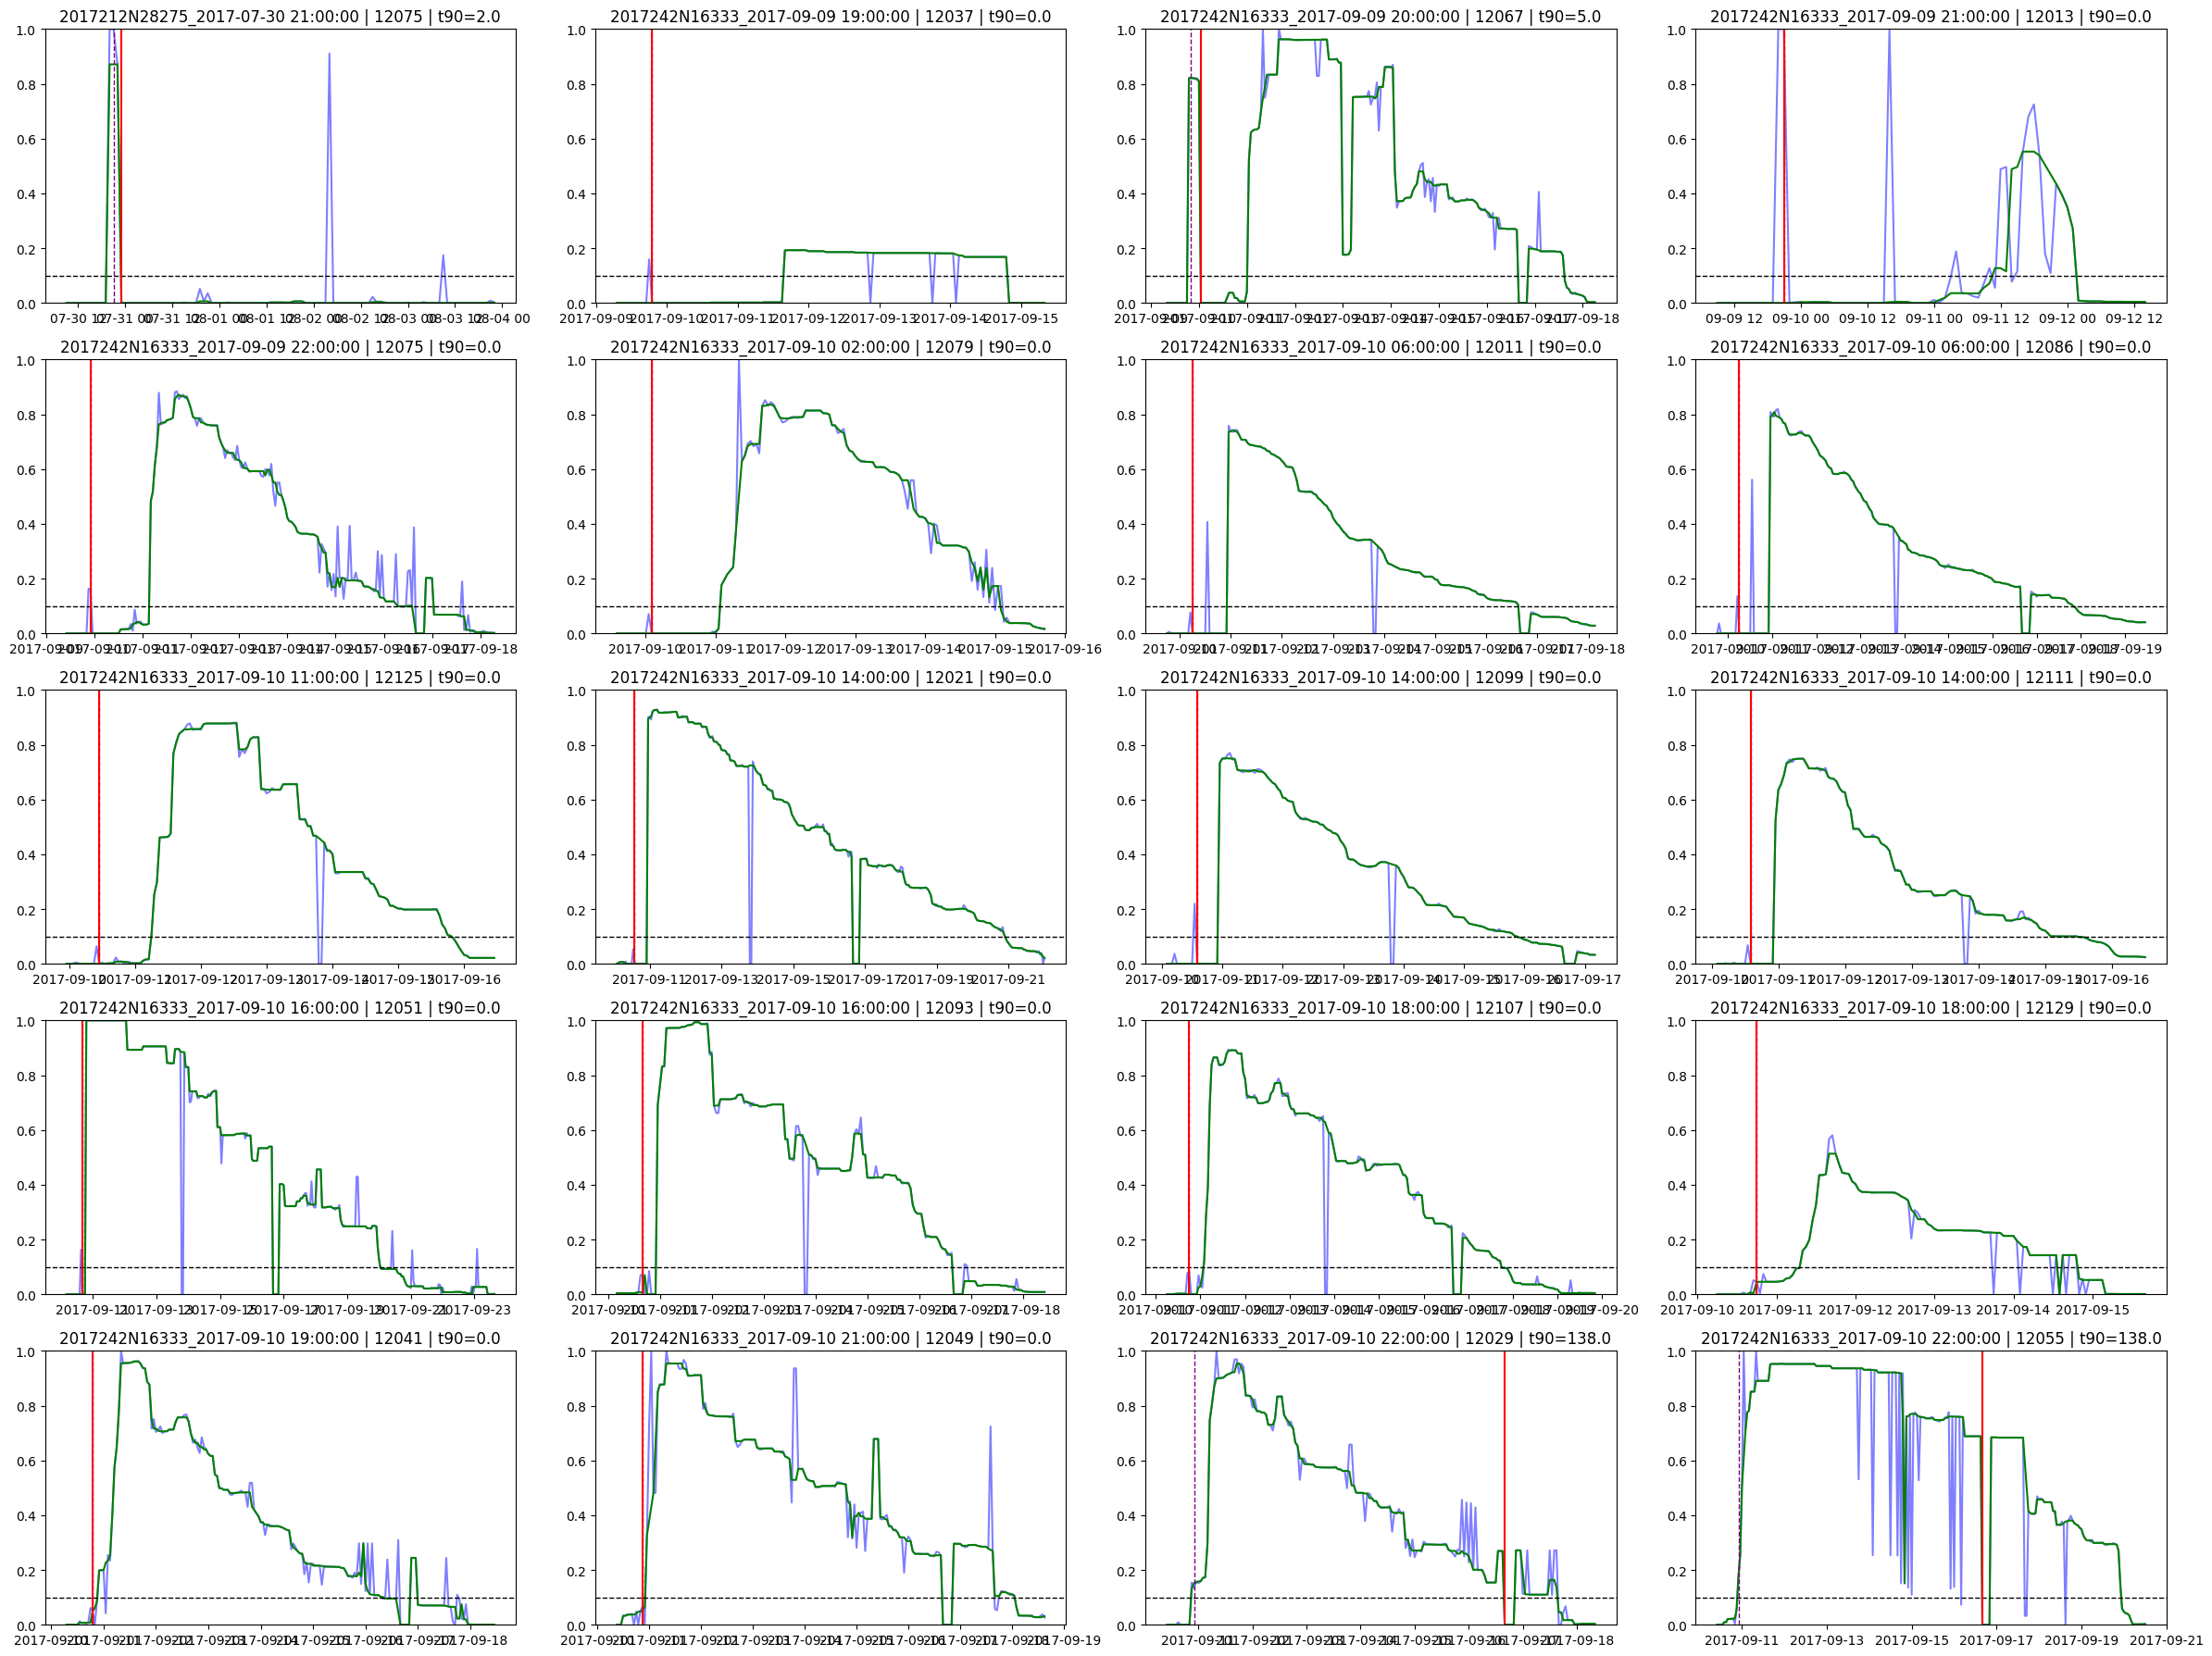

In [10]:
# CELL — Visual validation of t90 on 20 events

import matplotlib.pyplot as plt

chunk = 1
plots_per_chunk = 20

groups = model_df[["event_id", "CountyFIPS", "t90"]].copy()

start = (chunk - 1) * plots_per_chunk
end = start + plots_per_chunk

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]
    t90 = row["t90"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county_fips)
    ].sort_values("datetime")

    event_start = g["event_start"].iloc[0]

    ax.set_visible(True)

    # Raw
    ax.plot(g["datetime"], g["outageFraction"], color="blue", alpha=0.5, label="raw")

    # Cleaned
    ax.plot(g["datetime"], g["outage_clean"], color="green", linewidth=1.5, label="clean")

    # Threshold
    ax.axhline(0.1, linestyle="--", color="black", linewidth=1)

    # Event start
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    # t90 point
    t90_time = event_start + pd.Timedelta(hours=t90)
    ax.axvline(t90_time, color="red", linestyle="-", linewidth=1.5)

    ax.set_title(f"{event_id} | {county_fips} | t90={t90:.1f}")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

this is clearly wrong! need to change logic

Last downward-transition target summary:
count     90.000000
mean     143.552083
std      104.756440
min        1.885185
25%       75.481588
50%      127.678903
75%      170.772337
max      551.473029
Name: t90_lastcross, dtype: float64
Censored fraction: 0.0


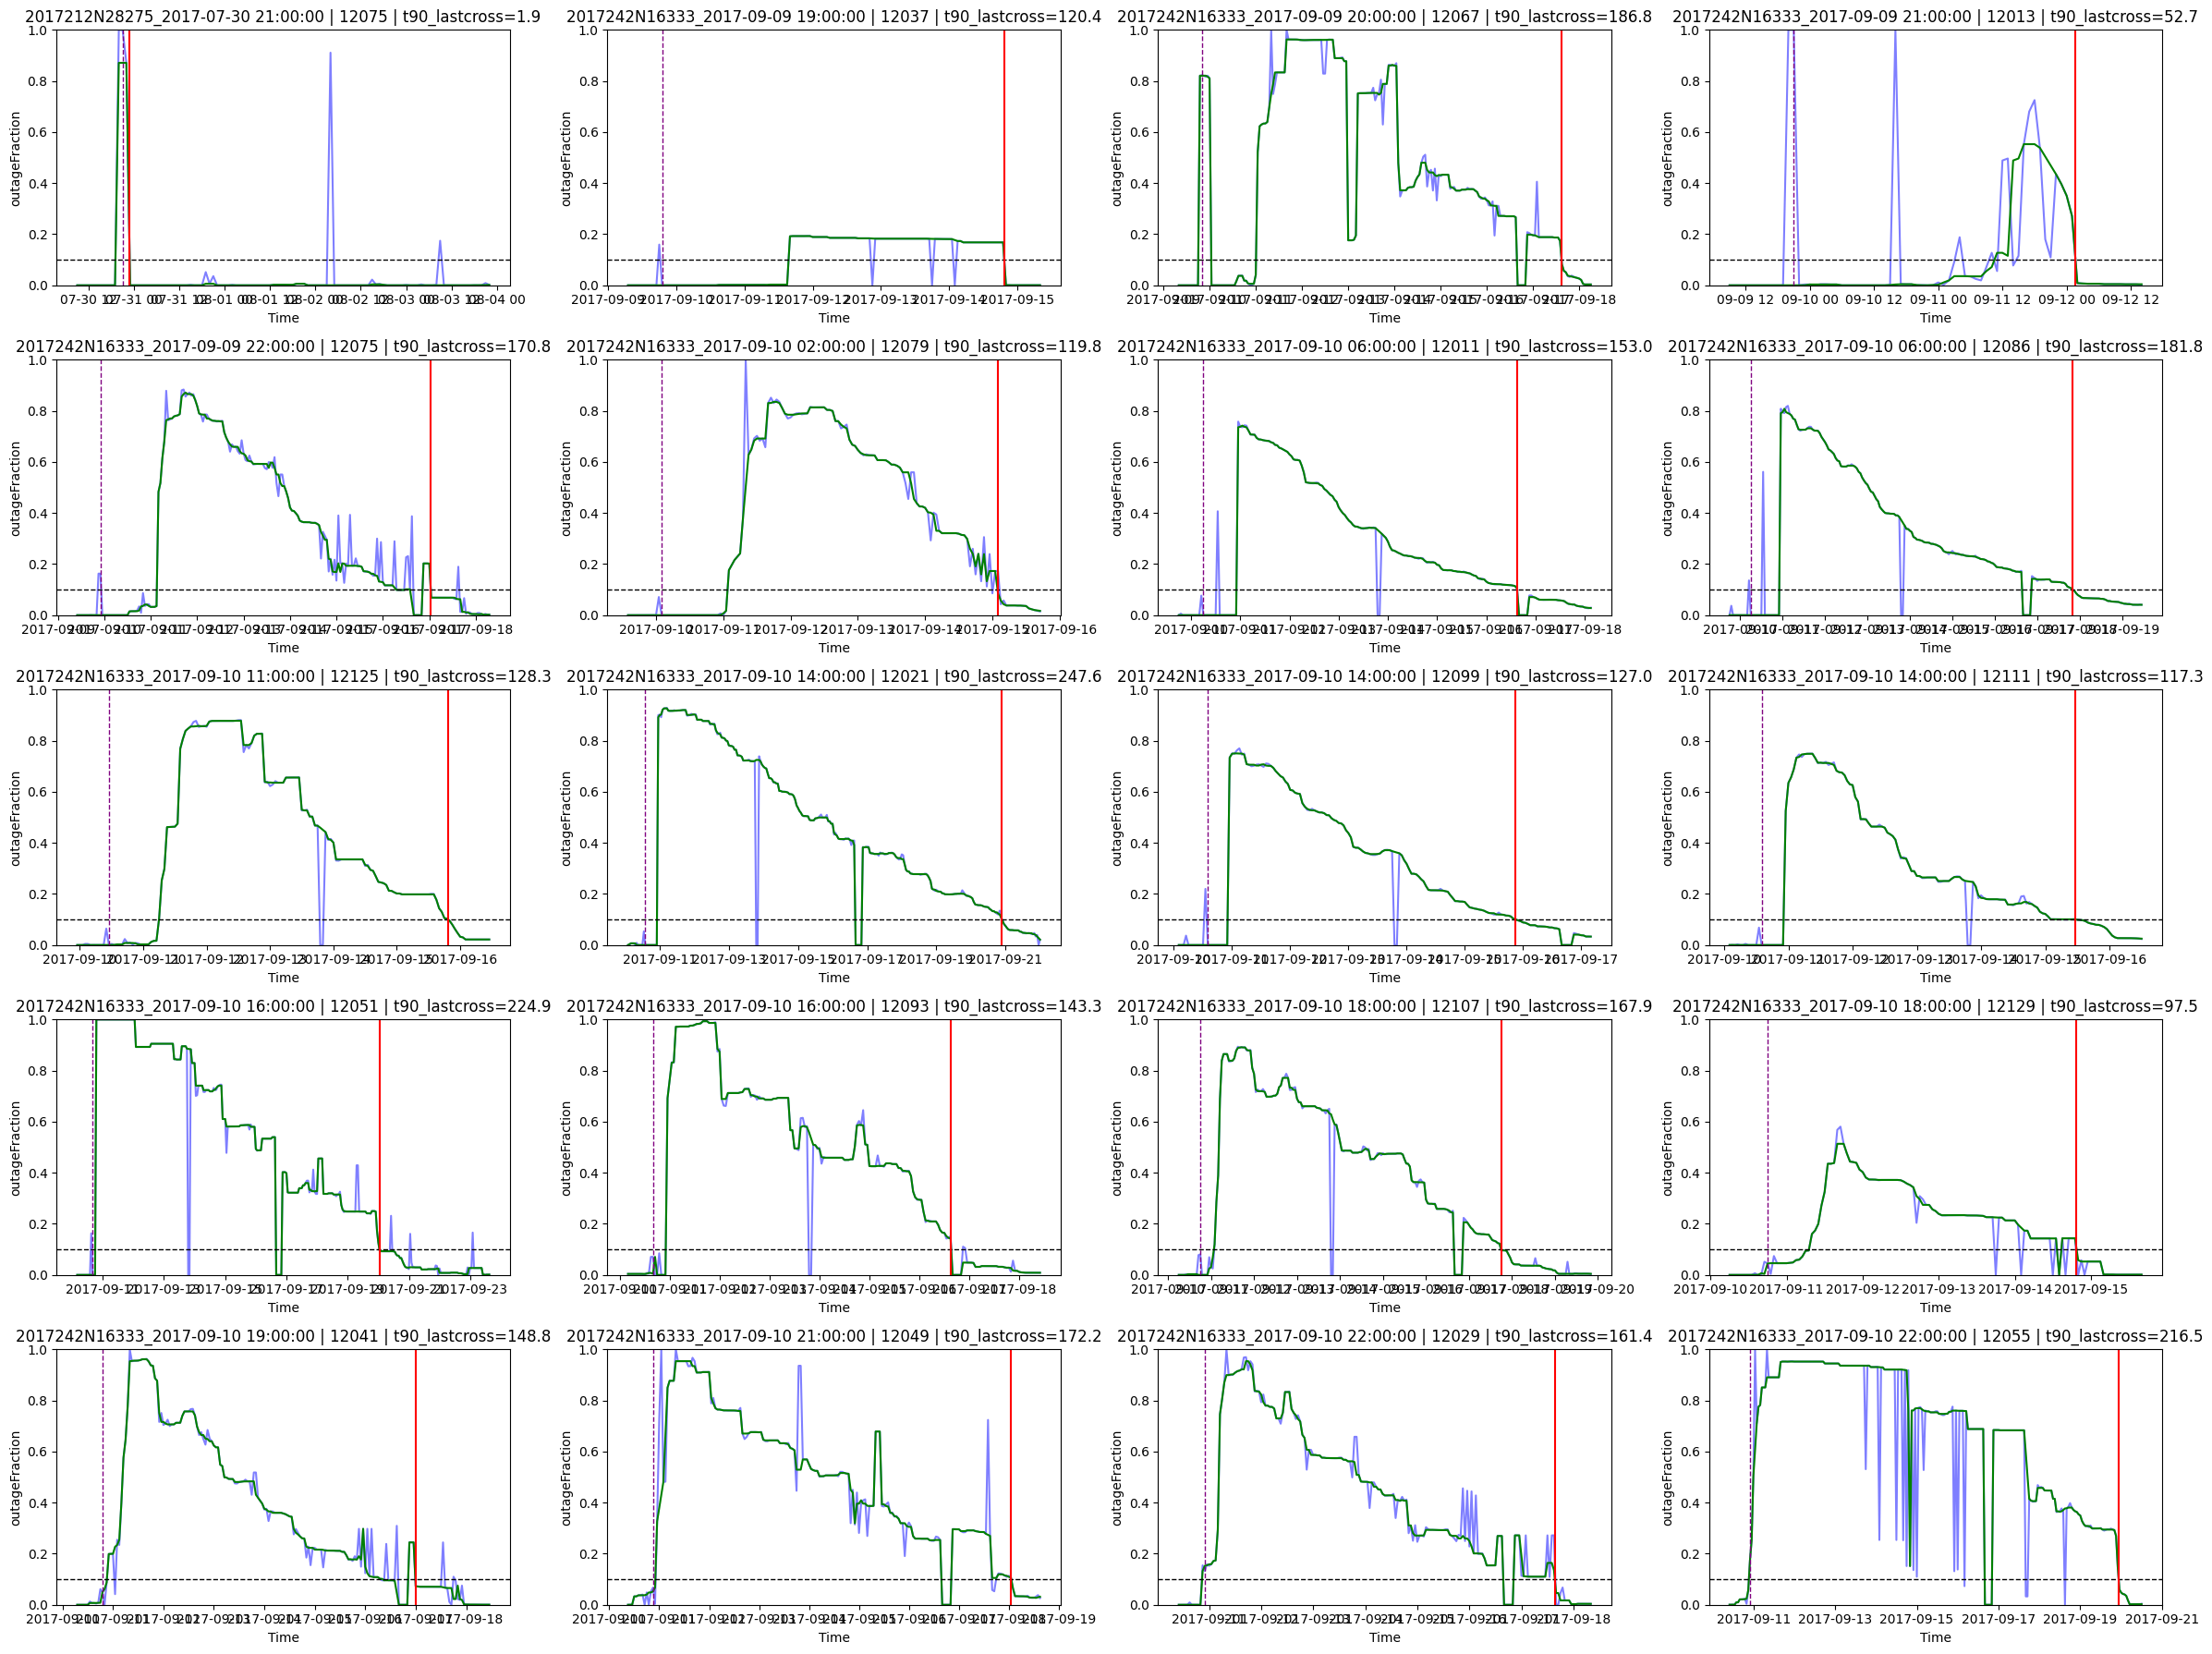

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.1
chunk = 1
plots_per_chunk = 20

source_df = df.copy()

if "CountyFIPS" not in source_df.columns:
    if "geoid" in source_df.columns:
        source_df["CountyFIPS"] = source_df["geoid"].astype(str).str.zfill(5)
    else:
        raise KeyError(f"CountyFIPS missing and geoid unavailable. Columns: {source_df.columns.tolist()}")

source_df["CountyFIPS"] = source_df["CountyFIPS"].astype(str).str.zfill(5)
source_df["datetime"] = pd.to_datetime(source_df["datetime"])
source_df["event_start"] = pd.to_datetime(source_df["event_start"])

def last_downward_transition(g, threshold=0.1):
    g = g.sort_values("datetime").copy()
    start = g["event_start"].iloc[0]

    post = g[g["datetime"] >= start].copy()
    y = post["outage_clean"].to_numpy(dtype=float)
    t = post["datetime"].to_numpy()

    if len(y) < 2:
        return None, 0.0, 1

    above_to_below = (y[:-1] > threshold) & (y[1:] <= threshold)
    idx = np.where(above_to_below)[0]

    if len(idx) == 0:
        # no downward crossing after event start
        return None, g["duration_hours"].max(), 1

    i = idx[-1]  # last downward transition
    y0, y1 = y[i], y[i + 1]
    t0 = pd.Timestamp(t[i])
    t1 = pd.Timestamp(t[i + 1])

    if y0 == y1:
        cross_time = t1
    else:
        frac = (y0 - threshold) / (y0 - y1)
        cross_time = t0 + (t1 - t0) * frac

    t_hours = (cross_time - start) / pd.Timedelta(hours=1)
    return cross_time, float(t_hours), 0

def compute_t90_last_transition(g):
    cross_time, t_val, censored = last_downward_transition(g, threshold=threshold)
    return pd.Series({
        "t90_lastcross": t_val,
        "censored_lastcross": censored,
        "crossing_time_lastcross": cross_time,
    })

last_targets = (
    source_df.groupby(["event_id", "CountyFIPS"])
    .apply(compute_t90_last_transition)
    .reset_index()
)

print("Last downward-transition target summary:")
print(last_targets["t90_lastcross"].describe())
print("Censored fraction:", last_targets["censored_lastcross"].mean())

groups = (
    last_targets[["event_id", "CountyFIPS", "t90_lastcross"]]
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start_idx = (chunk - 1) * plots_per_chunk
end_idx = min(start_idx + plots_per_chunk, len(groups))

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start_idx:end_idx].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]
    t_val = row["t90_lastcross"]

    g = source_df[
        (source_df["event_id"] == event_id) &
        (source_df["CountyFIPS"] == county_fips)
    ].sort_values("datetime").copy()

    event_start = g["event_start"].iloc[0]
    cross_time, _, censored = last_downward_transition(g, threshold=threshold)

    ax.set_visible(True)
    ax.plot(g["datetime"], g["outageFraction"], color="blue", alpha=0.5, label="raw")
    ax.plot(g["datetime"], g["outage_clean"], color="green", linewidth=1.5, label="clean")
    ax.axhline(threshold, linestyle="--", color="black", linewidth=1)
    ax.axvline(event_start, color="purple", linestyle="--", linewidth=1)

    if cross_time is not None:
        ax.axvline(cross_time, color="red", linewidth=1.5)

    ax.set_title(f"{event_id} | {county_fips} | t90_lastcross={t_val:.1f}")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")

plt.tight_layout()
plt.show()

^ Excellent, finally functional. just note a few shortcomings/caveats:
- smoothing is imperfect
- it's using the last instance of >0.1 to <=0.1, interpolating, choosing that time; regardless of how big the outage really was. also may not need interpolation

In [18]:
# CELL — Linear regression + Leave-One-Storm-Out CV

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

# -----------------------
# Prepare modelling data
# -----------------------

# Use your final dataset (adjust name if needed)
data = model_df.copy()

# Use the new target (last crossing)
# Replace this if you renamed it differently
data = data.merge(
    last_targets[["event_id", "CountyFIPS", "t90_lastcross"]],
    on=["event_id", "CountyFIPS"],
    how="left"
)

data["target"] = data["t90_lastcross"]

# Drop any missing
data = data.dropna(subset=["target"])

# Extract storm ID for LOSO CV
data["storm_id"] = data["event_id"].str.split("_").str[0]

print("Final modelling rows:", len(data))
print("Unique storms:", data["storm_id"].nunique())

# -----------------------
# Features
# -----------------------

numeric_features = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop"
]

categorical_features = ["CountyFIPS"]

# -----------------------
# Preprocessing
# -----------------------

numeric_transformer = StandardScaler() if STANDARDIZE_NUMERIC else "passthrough"

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# -----------------------
# Model pipeline
# -----------------------

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# -----------------------
# Leave-One-Storm-Out CV
# -----------------------

storms = data["storm_id"].unique()

maes = []
rmses = []

for storm in storms:
    train = data[data["storm_id"] != storm]
    test = data[data["storm_id"] == storm]

    X_train = train[numeric_features + categorical_features]
    y_train = train["target"]

    X_test = test[numeric_features + categorical_features]
    y_test = test["target"]

    # Fit
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    maes.append(mae)
    rmses.append(rmse)

    print(f"Storm {storm} | n={len(test)} | MAE={mae:.2f} | RMSE={rmse:.2f}")

# -----------------------
# Overall performance
# -----------------------

print("\nOverall performance:")
print(f"Mean MAE: {np.mean(maes):.2f}")
print(f"Mean RMSE: {np.mean(rmses):.2f}")

Final modelling rows: 90
Unique storms: 7
Storm 2017212N28275 | n=1 | MAE=67.07 | RMSE=67.07
Storm 2017242N16333 | n=49 | MAE=289.24 | RMSE=344.13
Storm 2018280N18273 | n=14 | MAE=186.47 | RMSE=245.78
Storm 2020256N25281 | n=3 | MAE=115.99 | RMSE=118.61
Storm 2021182N09317 | n=1 | MAE=36.28 | RMSE=36.28
Storm 2021222N14301 | n=3 | MAE=196.97 | RMSE=223.36
Storm 2022263N10313 | n=19 | MAE=141.88 | RMSE=175.78

Overall performance:
Mean MAE: 147.70
Mean RMSE: 173.00


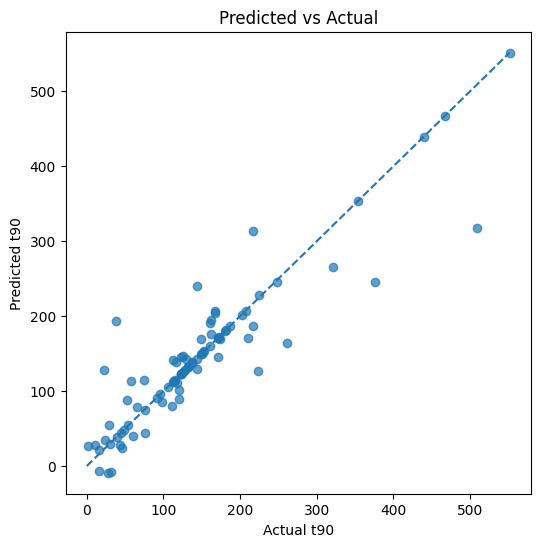

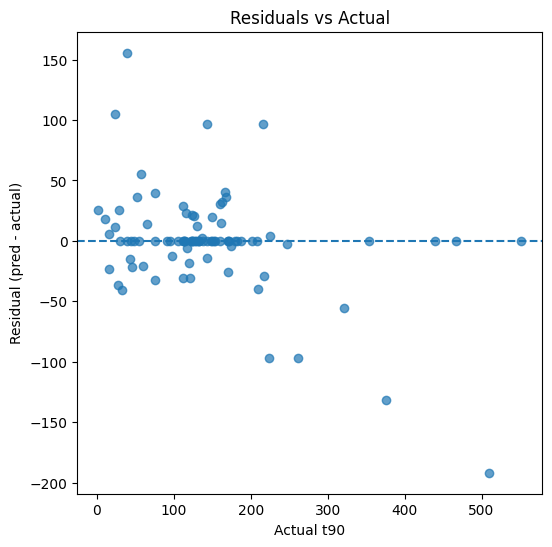


MAE by storm:
('2021222N14301', 3, 90.73242460649992)
('2018280N18273', 14, 32.19360028522203)
('2017212N28275', 1, 25.501330922275976)
('2022263N10313', 19, 24.844409619996252)
('2021182N09317', 1, 14.723306628319186)
('2017242N16333', 49, 14.554651297001312)
('2020256N25281', 3, 0.00020718221180378768)


In [20]:
# CELL — Diagnostics plots

import matplotlib.pyplot as plt

# Refit on full data to get global predictions
X = data[numeric_features + categorical_features]
y = data["target"]

model.fit(X, y)
preds = model.predict(X)

# -----------------------
# 1. Predicted vs Actual
# -----------------------

plt.figure(figsize=(6,6))
plt.scatter(y, preds, alpha=0.7)
plt.plot([0, max(y)], [0, max(y)], linestyle="--")
plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("Predicted vs Actual")
plt.show()

# -----------------------
# 2. Residuals
# -----------------------

residuals = preds - y

plt.figure(figsize=(6,6))
plt.scatter(y, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Actual t90")
plt.ylabel("Residual (pred - actual)")
plt.title("Residuals vs Actual")
plt.show()

# -----------------------
# 3. Error by storm
# -----------------------

storm_errors = []

for storm in storms:
    subset = data[data["storm_id"] == storm]
    X_s = subset[numeric_features + categorical_features]
    y_s = subset["target"]

    preds_s = model.predict(X_s)
    mae_s = mean_absolute_error(y_s, preds_s)

    storm_errors.append((storm, len(subset), mae_s))

storm_errors = sorted(storm_errors, key=lambda x: x[2], reverse=True)

print("\nMAE by storm:")
for s in storm_errors:
    print(s)

C:\Users\teaching\AppData\Local\Temp\ipykernel_41532\308071103.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(storm_vals))


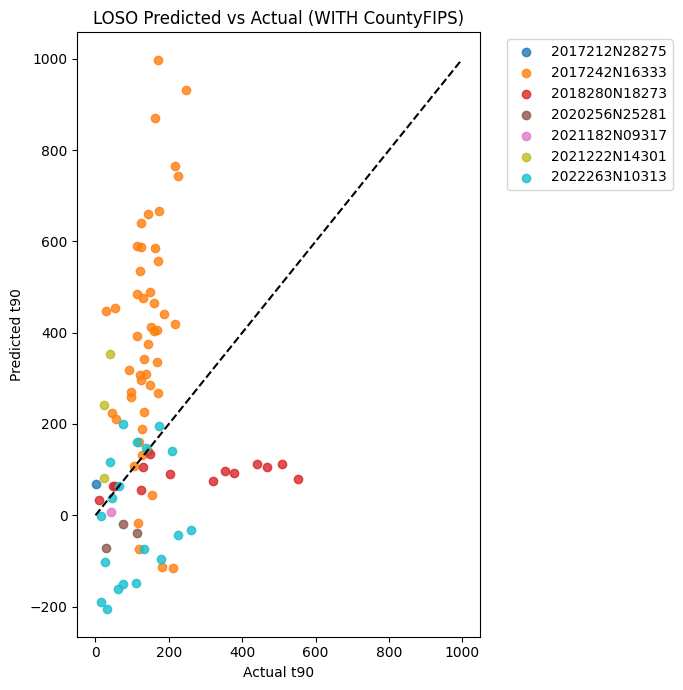

In [25]:
# CELL — LOSO predicted vs actual WITH CountyFIPS

all_actual = []
all_pred = []
all_storms = []

for storm in storms:
    train = data[data["storm_id"] != storm]
    test = data[data["storm_id"] == storm]

    X_train = train[numeric_features + categorical_features]
    y_train = train["target"]

    X_test = test[numeric_features + categorical_features]
    y_test = test["target"]

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    all_actual.extend(y_test.values)
    all_pred.extend(preds)
    all_storms.extend([storm] * len(y_test))

all_actual = np.array(all_actual)
all_pred = np.array(all_pred)
all_storms = np.array(all_storms)

# Plot
plt.figure(figsize=(7,7))

storm_vals = sorted(np.unique(all_storms))
cmap = plt.cm.get_cmap("tab10", len(storm_vals))
color_map = {s: cmap(i) for i, s in enumerate(storm_vals)}

for s in storm_vals:
    mask = all_storms == s
    plt.scatter(all_actual[mask], all_pred[mask],
                color=color_map[s], label=s, alpha=0.8)

mx = max(all_actual.max(), all_pred.max())
plt.plot([0, mx], [0, mx], linestyle="--", color="black")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("LOSO Predicted vs Actual (WITH CountyFIPS)")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

variable importance (for linear models, this is not very fancy, just coefficients):

Numeric features
- Because you scaled them:
- coefficient = effect per 1 standard deviation increase

CountyFIPS
- Each coefficient is:
- deviation from baseline county
- Large values = strong memorisation.


Numeric feature coefficients:
           feature       coef
3  pressure_min_7d -65.769996
1     mean_gust_7d -36.813080
2  total_precip_7d -26.581545
0         max_gust -14.479187
4       county_pop   5.415979

Top 10 CountyFIPS effects:
             feature        coef
34  CountyFIPS_12063  328.294540
26  CountyFIPS_12045  257.416121
7   CountyFIPS_12005  244.285069
20  CountyFIPS_12033  145.360566
30  CountyFIPS_12053 -128.847245
59  CountyFIPS_12115  125.995975
13  CountyFIPS_12017 -120.948957
61  CountyFIPS_12119 -115.667611
52  CountyFIPS_12101 -113.900771
68  CountyFIPS_12133  109.830295


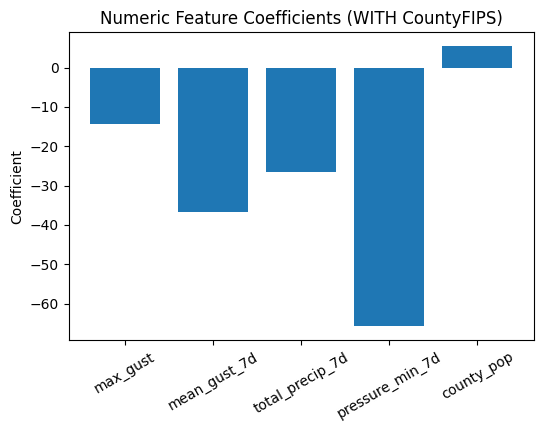

In [29]:
# CELL — Extract coefficients (WITH CountyFIPS)

import pandas as pd
import numpy as np

# Fit model on full data (for interpretability only)
X = data[numeric_features + categorical_features]
y = data["target"]

model.fit(X, y)

# -----------------------
# Get feature names
# -----------------------

# numeric names
num_names = numeric_features

# categorical names (after one-hot)
ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_names, cat_names])

# -----------------------
# Get coefficients
# -----------------------

coefs = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
})

# -----------------------
# Split numeric vs county
# -----------------------

num_df = coef_df[coef_df["feature"].isin(num_names)].copy()
county_df = coef_df[~coef_df["feature"].isin(num_names)].copy()

print("\nNumeric feature coefficients:")
print(num_df.sort_values("coef", key=abs, ascending=False))

print("\nTop 10 CountyFIPS effects:")
print(county_df.sort_values("coef", key=abs, ascending=False).head(10))

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(num_df["feature"], num_df["coef"])
plt.title("Numeric Feature Coefficients (WITH CountyFIPS)")
plt.ylabel("Coefficient")
plt.xticks(rotation=30)
plt.show()

^ very interesting... time is positively correlated with population, meanwhile all the weather features are just used to temper that county correlation

In [27]:
print("\nCounty coefficient magnitude summary:")
print(county_df["coef"].abs().describe())


County coefficient magnitude summary:
count     64.000000
mean      62.346675
std       58.877309
min        1.592583
25%       26.748981
50%       46.827004
75%       75.719087
max      328.294540
Name: coef, dtype: float64


C:\Users\teaching\AppData\Local\Temp\ipykernel_41532\1852753906.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  storm_cmap = plt.cm.get_cmap("tab10", len(storm_vals))
C:\Users\teaching\AppData\Local\Temp\ipykernel_41532\1852753906.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  county_cmap = plt.cm.get_cmap("nipy_spectral", len(county_vals))


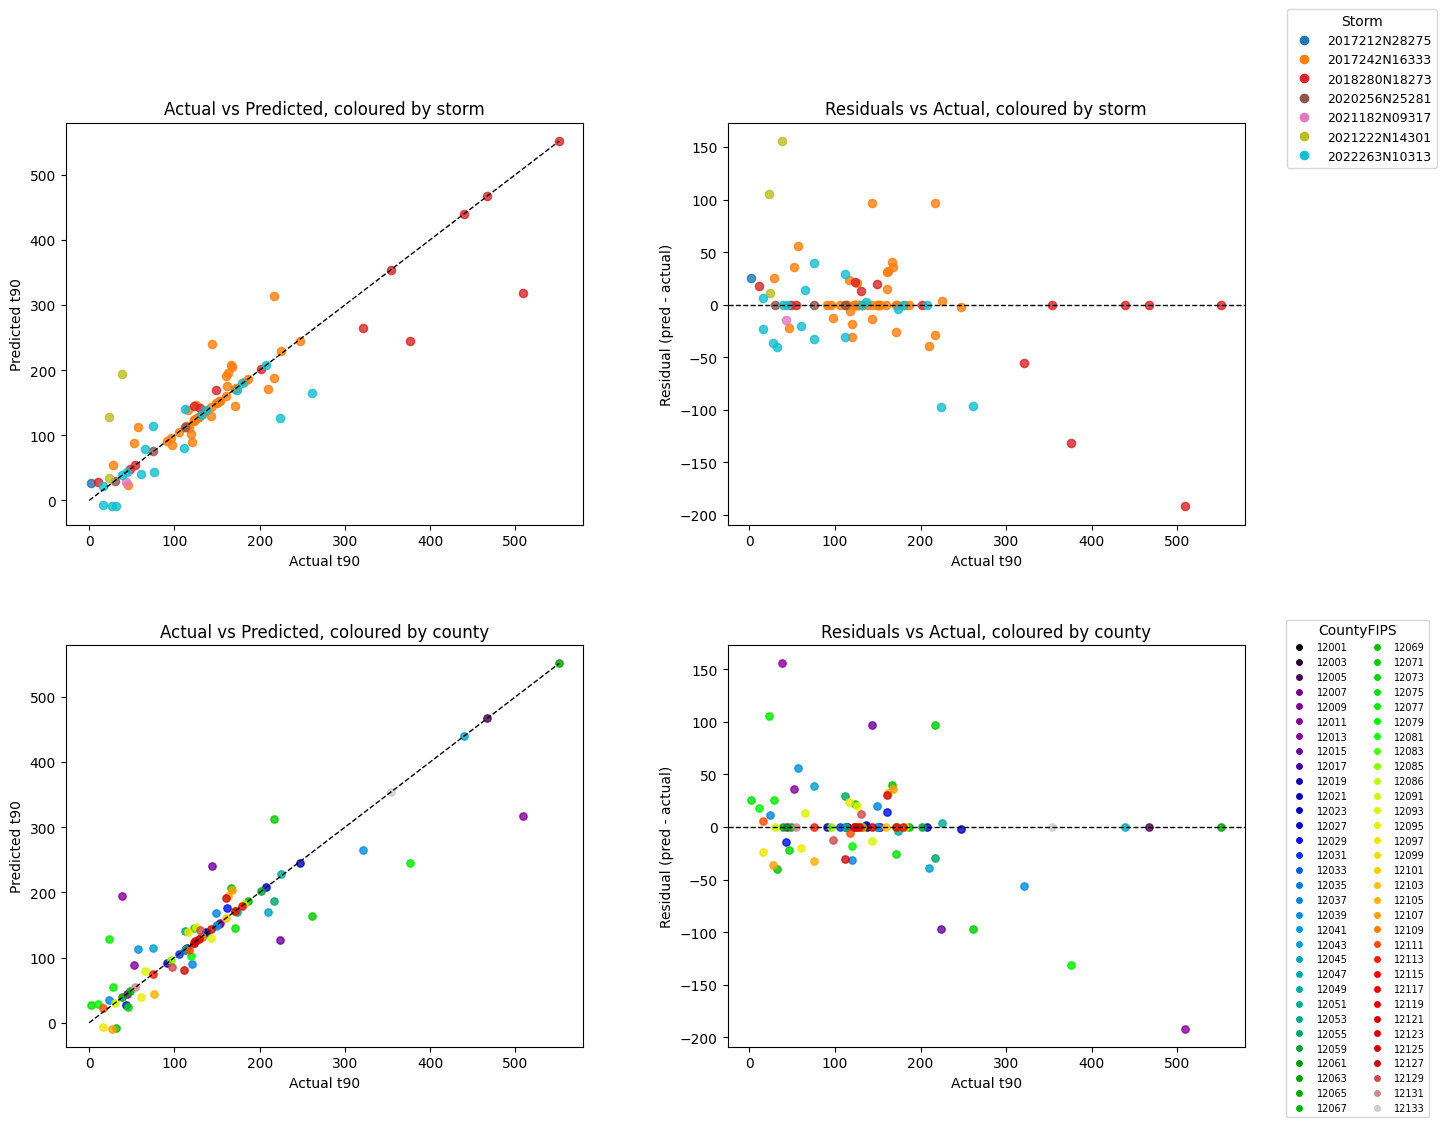

In [22]:
# CELL — 2x2 diagnostics coloured by storm and county

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

# -----------------------
# Refit on full data and store predictions
# -----------------------
plot_df = data.copy()

X = plot_df[numeric_features + categorical_features]
y = plot_df["target"]

model.fit(X, y)
plot_df["pred"] = model.predict(X)
plot_df["resid"] = plot_df["pred"] - plot_df["target"]

plot_df["storm_id"] = plot_df["event_id"].str.split("_").str[0]
plot_df["CountyFIPS"] = plot_df["CountyFIPS"].astype(str).str.zfill(5)

# -----------------------
# Colour maps
# -----------------------
storm_vals = sorted(plot_df["storm_id"].unique())
county_vals = sorted(plot_df["CountyFIPS"].unique())

storm_cmap = plt.cm.get_cmap("tab10", len(storm_vals))
county_cmap = plt.cm.get_cmap("nipy_spectral", len(county_vals))

storm_color = {s: storm_cmap(i) for i, s in enumerate(storm_vals)}
county_color = {c: county_cmap(i) for i, c in enumerate(county_vals)}

# -----------------------
# Figure layout
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
ax1, ax2, ax3, ax4 = axes.ravel()

# -----------------------
# 1) Actual vs Predicted — by storm
# -----------------------
for s in storm_vals:
    d = plot_df[plot_df["storm_id"] == s]
    ax1.scatter(d["target"], d["pred"], color=storm_color[s], alpha=0.8, s=35, label=s)

mx = max(plot_df["target"].max(), plot_df["pred"].max())
ax1.plot([0, mx], [0, mx], linestyle="--", color="black", linewidth=1)
ax1.set_title("Actual vs Predicted, coloured by storm")
ax1.set_xlabel("Actual t90")
ax1.set_ylabel("Predicted t90")

# -----------------------
# 2) Residuals vs Actual — by storm
# -----------------------
for s in storm_vals:
    d = plot_df[plot_df["storm_id"] == s]
    ax2.scatter(d["target"], d["resid"], color=storm_color[s], alpha=0.8, s=35, label=s)

ax2.axhline(0, linestyle="--", color="black", linewidth=1)
ax2.set_title("Residuals vs Actual, coloured by storm")
ax2.set_xlabel("Actual t90")
ax2.set_ylabel("Residual (pred - actual)")

# -----------------------
# 3) Actual vs Predicted — by county
# -----------------------
for c in county_vals:
    d = plot_df[plot_df["CountyFIPS"] == c]
    ax3.scatter(d["target"], d["pred"], color=county_color[c], alpha=0.8, s=28, label=c)

ax3.plot([0, mx], [0, mx], linestyle="--", color="black", linewidth=1)
ax3.set_title("Actual vs Predicted, coloured by county")
ax3.set_xlabel("Actual t90")
ax3.set_ylabel("Predicted t90")

# -----------------------
# 4) Residuals vs Actual — by county
# -----------------------
for c in county_vals:
    d = plot_df[plot_df["CountyFIPS"] == c]
    ax4.scatter(d["target"], d["resid"], color=county_color[c], alpha=0.8, s=28, label=c)

ax4.axhline(0, linestyle="--", color="black", linewidth=1)
ax4.set_title("Residuals vs Actual, coloured by county")
ax4.set_xlabel("Actual t90")
ax4.set_ylabel("Residual (pred - actual)")

# -----------------------
# Legends outside
# -----------------------
storm_handles = [
    Line2D([0], [0], marker="o", color="w", label=s, markerfacecolor=storm_color[s], markersize=8)
    for s in storm_vals
]

county_handles = [
    Line2D([0], [0], marker="o", color="w", label=c, markerfacecolor=county_color[c], markersize=6)
    for c in county_vals
]

# leave room on the right for legends
plt.subplots_adjust(right=0.78, wspace=0.28, hspace=0.30)

fig.legend(
    handles=storm_handles,
    title="Storm",
    loc="upper left",
    bbox_to_anchor=(0.80, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

fig.legend(
    handles=county_handles,
    title="CountyFIPS",
    loc="upper left",
    bbox_to_anchor=(0.80, 0.47),
    frameon=True,
    fontsize=7,
    title_fontsize=10,
    ncol=2,
)

plt.show()

Now we try **without County** to see if it was memorising:

In [23]:
# CELL — LOSO CV without CountyFIPS

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------
# Features (NO CountyFIPS)
# -----------------------
numeric_features = [
    "max_gust",
    "mean_gust_7d",
    "total_precip_7d",
    "pressure_min_7d",
    "county_pop"
]

# -----------------------
# Preprocessing
# -----------------------
numeric_transformer = StandardScaler() if STANDARDIZE_NUMERIC else "passthrough"

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
    ]
)

model_nc = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# -----------------------
# LOSO CV
# -----------------------
data_nc = data.copy()

storms = data_nc["storm_id"].unique()

maes = []
rmses = []

print("LOSO CV (NO CountyFIPS)\n")

for storm in storms:
    train = data_nc[data_nc["storm_id"] != storm]
    test = data_nc[data_nc["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train = train["target"]

    X_test = test[numeric_features]
    y_test = test["target"]

    model_nc.fit(X_train, y_train)
    preds = model_nc.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    maes.append(mae)
    rmses.append(rmse)

    print(f"Storm {storm} | n={len(test)} | MAE={mae:.2f} | RMSE={rmse:.2f}")

print("\nOverall performance (NO CountyFIPS):")
print(f"Mean MAE: {np.mean(maes):.2f}")
print(f"Mean RMSE: {np.mean(rmses):.2f}")

LOSO CV (NO CountyFIPS)

Storm 2017212N28275 | n=1 | MAE=147.90 | RMSE=147.90
Storm 2017242N16333 | n=49 | MAE=184.97 | RMSE=215.20
Storm 2018280N18273 | n=14 | MAE=170.92 | RMSE=227.56
Storm 2020256N25281 | n=3 | MAE=112.83 | RMSE=115.00
Storm 2021182N09317 | n=1 | MAE=32.58 | RMSE=32.58
Storm 2021222N14301 | n=3 | MAE=98.41 | RMSE=108.43
Storm 2022263N10313 | n=19 | MAE=66.13 | RMSE=74.74

Overall performance (NO CountyFIPS):
Mean MAE: 116.25
Mean RMSE: 131.63


^ So, CountyFIPS was actually hurting generalization. So for LOSO-CV it was bad. 

C:\Users\teaching\AppData\Local\Temp\ipykernel_41532\817051298.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(storm_vals))


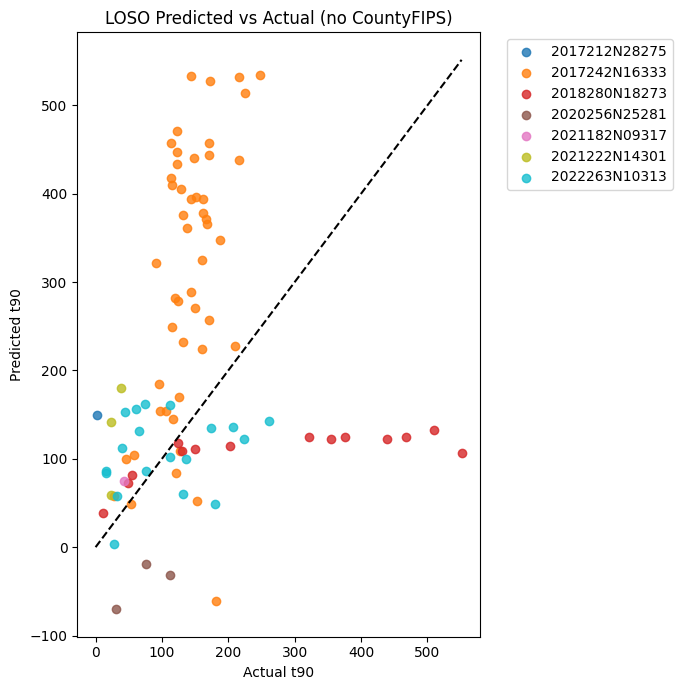

In [24]:
# CELL — Out-of-sample predicted vs actual (LOSO), coloured by storm

import matplotlib.pyplot as plt
import numpy as np

data_nc = data.copy()

storms = data_nc["storm_id"].unique()

all_actual = []
all_pred = []
all_storms = []

for storm in storms:
    train = data_nc[data_nc["storm_id"] != storm]
    test = data_nc[data_nc["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train = train["target"]

    X_test = test[numeric_features]
    y_test = test["target"]

    model_nc.fit(X_train, y_train)
    preds = model_nc.predict(X_test)

    all_actual.extend(y_test.values)
    all_pred.extend(preds)
    all_storms.extend([storm] * len(y_test))

# Convert
all_actual = np.array(all_actual)
all_pred = np.array(all_pred)
all_storms = np.array(all_storms)

# -----------------------
# Plot
# -----------------------

storm_vals = sorted(np.unique(all_storms))
cmap = plt.cm.get_cmap("tab10", len(storm_vals))
color_map = {s: cmap(i) for i, s in enumerate(storm_vals)}

plt.figure(figsize=(7,7))

for s in storm_vals:
    mask = all_storms == s
    plt.scatter(all_actual[mask], all_pred[mask],
                color=color_map[s], label=s, alpha=0.8)

mx = max(all_actual.max(), all_pred.max())
plt.plot([0, mx], [0, mx], linestyle="--", color="black")

plt.xlabel("Actual t90")
plt.ylabel("Predicted t90")
plt.title("LOSO Predicted vs Actual (no CountyFIPS)")

# Legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


Numeric feature coefficients (NO CountyFIPS):
           feature       coef
3  pressure_min_7d -65.425212
0         max_gust -39.047451
1     mean_gust_7d -34.391471
2  total_precip_7d -10.458822
4       county_pop   7.841732


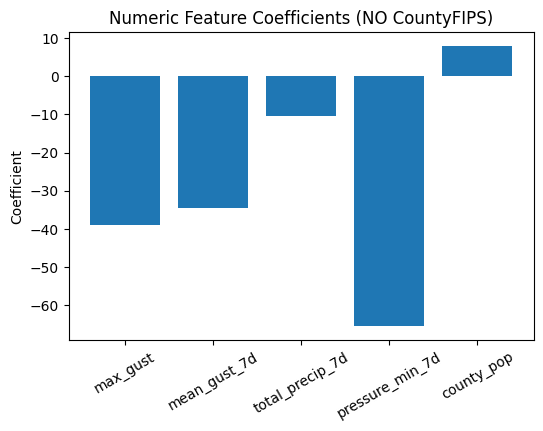


Feature correlation matrix:
                 max_gust  mean_gust_7d  total_precip_7d  pressure_min_7d  \
max_gust         1.000000     -0.094549         0.521432        -0.844975   
mean_gust_7d    -0.094549      1.000000         0.089134         0.358951   
total_precip_7d  0.521432      0.089134         1.000000        -0.439974   
pressure_min_7d -0.844975      0.358951        -0.439974         1.000000   
county_pop       0.367873      0.152783         0.231998        -0.151341   

                 county_pop  
max_gust           0.367873  
mean_gust_7d       0.152783  
total_precip_7d    0.231998  
pressure_min_7d   -0.151341  
county_pop         1.000000  


In [30]:
# CELL — Extract coefficients (NO CountyFIPS)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fit model WITHOUT CountyFIPS on full data (for interpretability only)
X = data_nc[numeric_features]
y = data_nc["target"]

model_nc.fit(X, y)

# -----------------------
# Coefficients
# -----------------------

coefs = model_nc.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "feature": numeric_features,
    "coef": coefs
})

print("\nNumeric feature coefficients (NO CountyFIPS):")
print(coef_df.sort_values("coef", key=abs, ascending=False))

# -----------------------
# Bar plot
# -----------------------

plt.figure(figsize=(6,4))
plt.bar(coef_df["feature"], coef_df["coef"])
plt.title("Numeric Feature Coefficients (NO CountyFIPS)")
plt.ylabel("Coefficient")
plt.xticks(rotation=30)
plt.show()

# -----------------------
# Correlation check
# -----------------------

print("\nFeature correlation matrix:")
print(data_nc[numeric_features].corr())

^ interesting, no correl between max gust and mean gust. maybe mean gust is a bad metric tbh

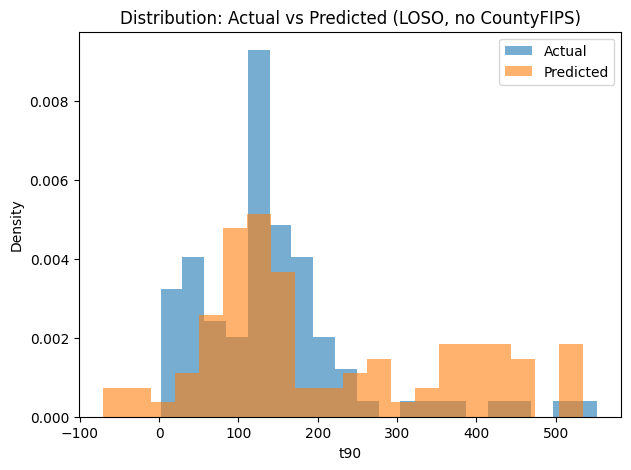

In [31]:
# CELL — Histogram of out-of-sample predictions vs actual (LOSO)

import matplotlib.pyplot as plt
import numpy as np

data_nc = data.copy()

storms = data_nc["storm_id"].unique()

all_actual = []
all_pred = []

for storm in storms:
    train = data_nc[data_nc["storm_id"] != storm]
    test = data_nc[data_nc["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train = train["target"]

    X_test = test[numeric_features]
    y_test = test["target"]

    model_nc.fit(X_train, y_train)
    preds = model_nc.predict(X_test)

    all_actual.extend(y_test.values)
    all_pred.extend(preds)

all_actual = np.array(all_actual)
all_pred = np.array(all_pred)

# -----------------------
# Plot
# -----------------------

plt.figure(figsize=(7,5))

bins = 20

plt.hist(all_actual, bins=bins, alpha=0.6, label="Actual", density=True)
plt.hist(all_pred, bins=bins, alpha=0.6, label="Predicted", density=True)

plt.xlabel("t90")
plt.ylabel("Density")
plt.title("Distribution: Actual vs Predicted (LOSO, no CountyFIPS)")
plt.legend()

plt.show()

Now let's try **log**

In [32]:
# CELL — define log target

import numpy as np

data_log = data.copy()

# log(1 + t90) to handle zeros safely
data_log["target"] = np.log1p(data_log["t90_lastcross"])

print("Log target summary:")
print(data_log["target"].describe())

Log target summary:
count    90.000000
mean      4.692992
std       0.857407
min       1.059589
25%       4.337044
50%       4.857307
75%       5.146170
max       6.314405
Name: target, dtype: float64


In [33]:
# CELL — LOSO CV with log(t90), no CountyFIPS

from sklearn.metrics import mean_absolute_error, mean_squared_error

storms = data_log["storm_id"].unique()

maes = []
rmses = []

print("LOSO CV (log target, no CountyFIPS)\n")

for storm in storms:
    train = data_log[data_log["storm_id"] != storm]
    test = data_log[data_log["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train = train["target"]

    X_test = test[numeric_features]
    y_test = test["target"]

    model_nc.fit(X_train, y_train)
    preds = model_nc.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    maes.append(mae)
    rmses.append(rmse)

    print(f"Storm {storm} | n={len(test)} | MAE={mae:.3f} | RMSE={rmse:.3f}")

print("\nOverall performance (log target):")
print(f"Mean MAE: {np.mean(maes):.3f}")
print(f"Mean RMSE: {np.mean(rmses):.3f}")

LOSO CV (log target, no CountyFIPS)

Storm 2017212N28275 | n=1 | MAE=3.400 | RMSE=3.400
Storm 2017242N16333 | n=49 | MAE=1.464 | RMSE=1.654
Storm 2018280N18273 | n=14 | MAE=1.027 | RMSE=1.209
Storm 2020256N25281 | n=3 | MAE=0.562 | RMSE=0.634
Storm 2021182N09317 | n=1 | MAE=0.065 | RMSE=0.065
Storm 2021222N14301 | n=3 | MAE=0.753 | RMSE=0.795
Storm 2022263N10313 | n=19 | MAE=0.504 | RMSE=0.592

Overall performance (log target):
Mean MAE: 1.111
Mean RMSE: 1.193


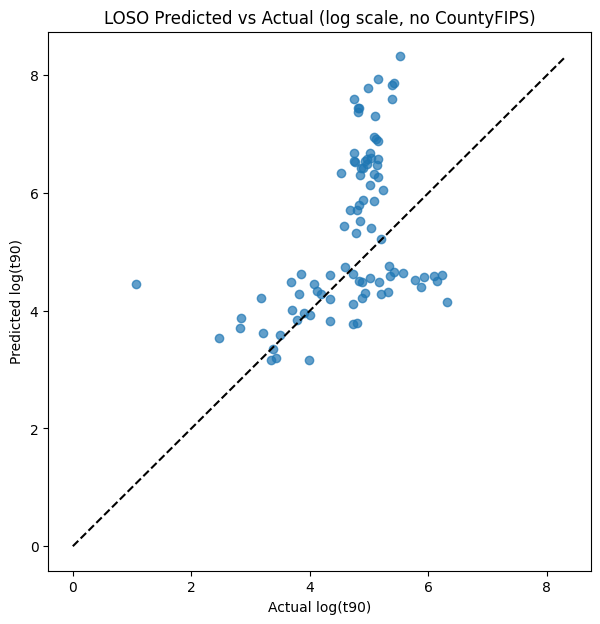

In [34]:
# CELL — predicted vs actual (log scale)

import matplotlib.pyplot as plt

all_actual = []
all_pred = []
all_storms = []

for storm in storms:
    train = data_log[data_log["storm_id"] != storm]
    test = data_log[data_log["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train = train["target"]

    X_test = test[numeric_features]
    y_test = test["target"]

    model_nc.fit(X_train, y_train)
    preds = model_nc.predict(X_test)

    all_actual.extend(y_test.values)
    all_pred.extend(preds)
    all_storms.extend([storm] * len(y_test))

all_actual = np.array(all_actual)
all_pred = np.array(all_pred)

plt.figure(figsize=(7,7))
plt.scatter(all_actual, all_pred, alpha=0.7)

mx = max(all_actual.max(), all_pred.max())
plt.plot([0, mx], [0, mx], linestyle="--", color="black")

plt.xlabel("Actual log(t90)")
plt.ylabel("Predicted log(t90)")
plt.title("LOSO Predicted vs Actual (log scale, no CountyFIPS)")

plt.show()

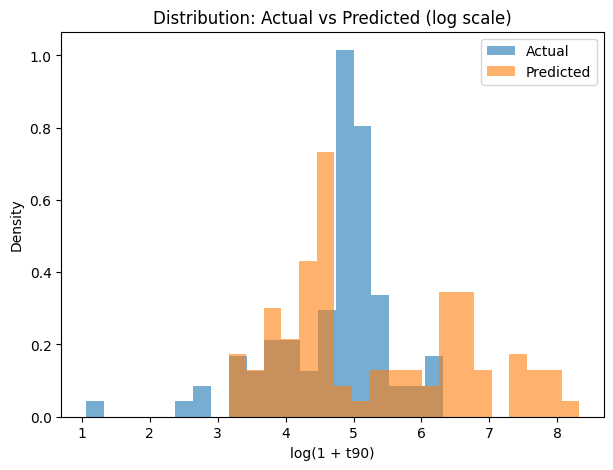

In [35]:
# CELL — histogram of log predictions

plt.figure(figsize=(7,5))

plt.hist(all_actual, bins=20, alpha=0.6, label="Actual", density=True)
plt.hist(all_pred, bins=20, alpha=0.6, label="Predicted", density=True)

plt.xlabel("log(1 + t90)")
plt.ylabel("Density")
plt.title("Distribution: Actual vs Predicted (log scale)")
plt.legend()

plt.show()

back to og space (not log) to comapre:

In [37]:
# CELL — LOSO CV evaluation in original (hours) space

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

storms = data_log["storm_id"].unique()

maes = []
rmses = []

print("LOSO CV (log model, evaluated in original t90 space)\n")

for storm in storms:
    train = data_log[data_log["storm_id"] != storm]
    test = data_log[data_log["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train_log = train["target"]

    X_test = test[numeric_features]
    y_test_log = test["target"]

    # Fit
    model_nc.fit(X_train, y_train_log)

    # Predict (log space)
    preds_log = model_nc.predict(X_test)

    # Convert back to original space
    preds = np.expm1(preds_log)
    actual = np.expm1(y_test_log)

    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))

    maes.append(mae)
    rmses.append(rmse)

    print(f"Storm {storm} | n={len(test)} | MAE={mae:.2f} | RMSE={rmse:.2f}")

print("\nOverall performance (original space):")
print(f"Mean MAE: {np.mean(maes):.2f}")
print(f"Mean RMSE: {np.mean(rmses):.2f}")

LOSO CV (log model, evaluated in original t90 space)

Storm 2017212N28275 | n=1 | MAE=83.58 | RMSE=83.58
Storm 2017242N16333 | n=49 | MAE=737.89 | RMSE=1110.49
Storm 2018280N18273 | n=14 | MAE=192.23 | RMSE=253.02
Storm 2020256N25281 | n=3 | MAE=35.36 | RMSE=43.82
Storm 2021182N09317 | n=1 | MAE=2.92 | RMSE=2.92
Storm 2021222N14301 | n=3 | MAE=35.23 | RMSE=38.77
Storm 2022263N10313 | n=19 | MAE=48.30 | RMSE=65.68

Overall performance (original space):
Mean MAE: 162.22
Mean RMSE: 228.33


C:\Users\teaching\AppData\Local\Temp\ipykernel_41532\4268468380.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(storm_vals))


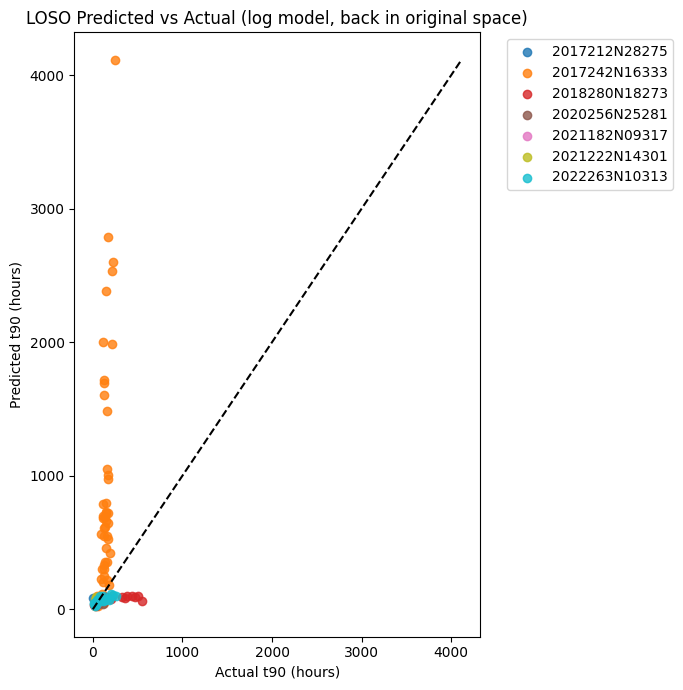

In [39]:
# CELL — Predicted vs Actual in original t90 space (LOSO, log model)

import matplotlib.pyplot as plt
import numpy as np

all_actual = []
all_pred = []
all_storms = []

for storm in storms:
    train = data_log[data_log["storm_id"] != storm]
    test = data_log[data_log["storm_id"] == storm]

    X_train = train[numeric_features]
    y_train_log = train["target"]

    X_test = test[numeric_features]
    y_test_log = test["target"]

    model_nc.fit(X_train, y_train_log)
    preds_log = model_nc.predict(X_test)

    # Convert back to original space
    preds = np.expm1(preds_log)
    actual = np.expm1(y_test_log)

    all_actual.extend(actual)
    all_pred.extend(preds)
    all_storms.extend([storm] * len(actual))

all_actual = np.array(all_actual)
all_pred = np.array(all_pred)
all_storms = np.array(all_storms)

# -----------------------
# Plot
# -----------------------

storm_vals = sorted(np.unique(all_storms))
cmap = plt.cm.get_cmap("tab10", len(storm_vals))
color_map = {s: cmap(i) for i, s in enumerate(storm_vals)}

plt.figure(figsize=(7,7))

for s in storm_vals:
    mask = all_storms == s
    plt.scatter(all_actual[mask], all_pred[mask],
                color=color_map[s], label=s, alpha=0.8)

mx = max(all_actual.max(), all_pred.max())
plt.plot([0, mx], [0, mx], linestyle="--", color="black")

plt.xlabel("Actual t90 (hours)")
plt.ylabel("Predicted t90 (hours)")
plt.title("LOSO Predicted vs Actual (log model, back in original space)")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Simple visualisation for 20 FL events at a time:

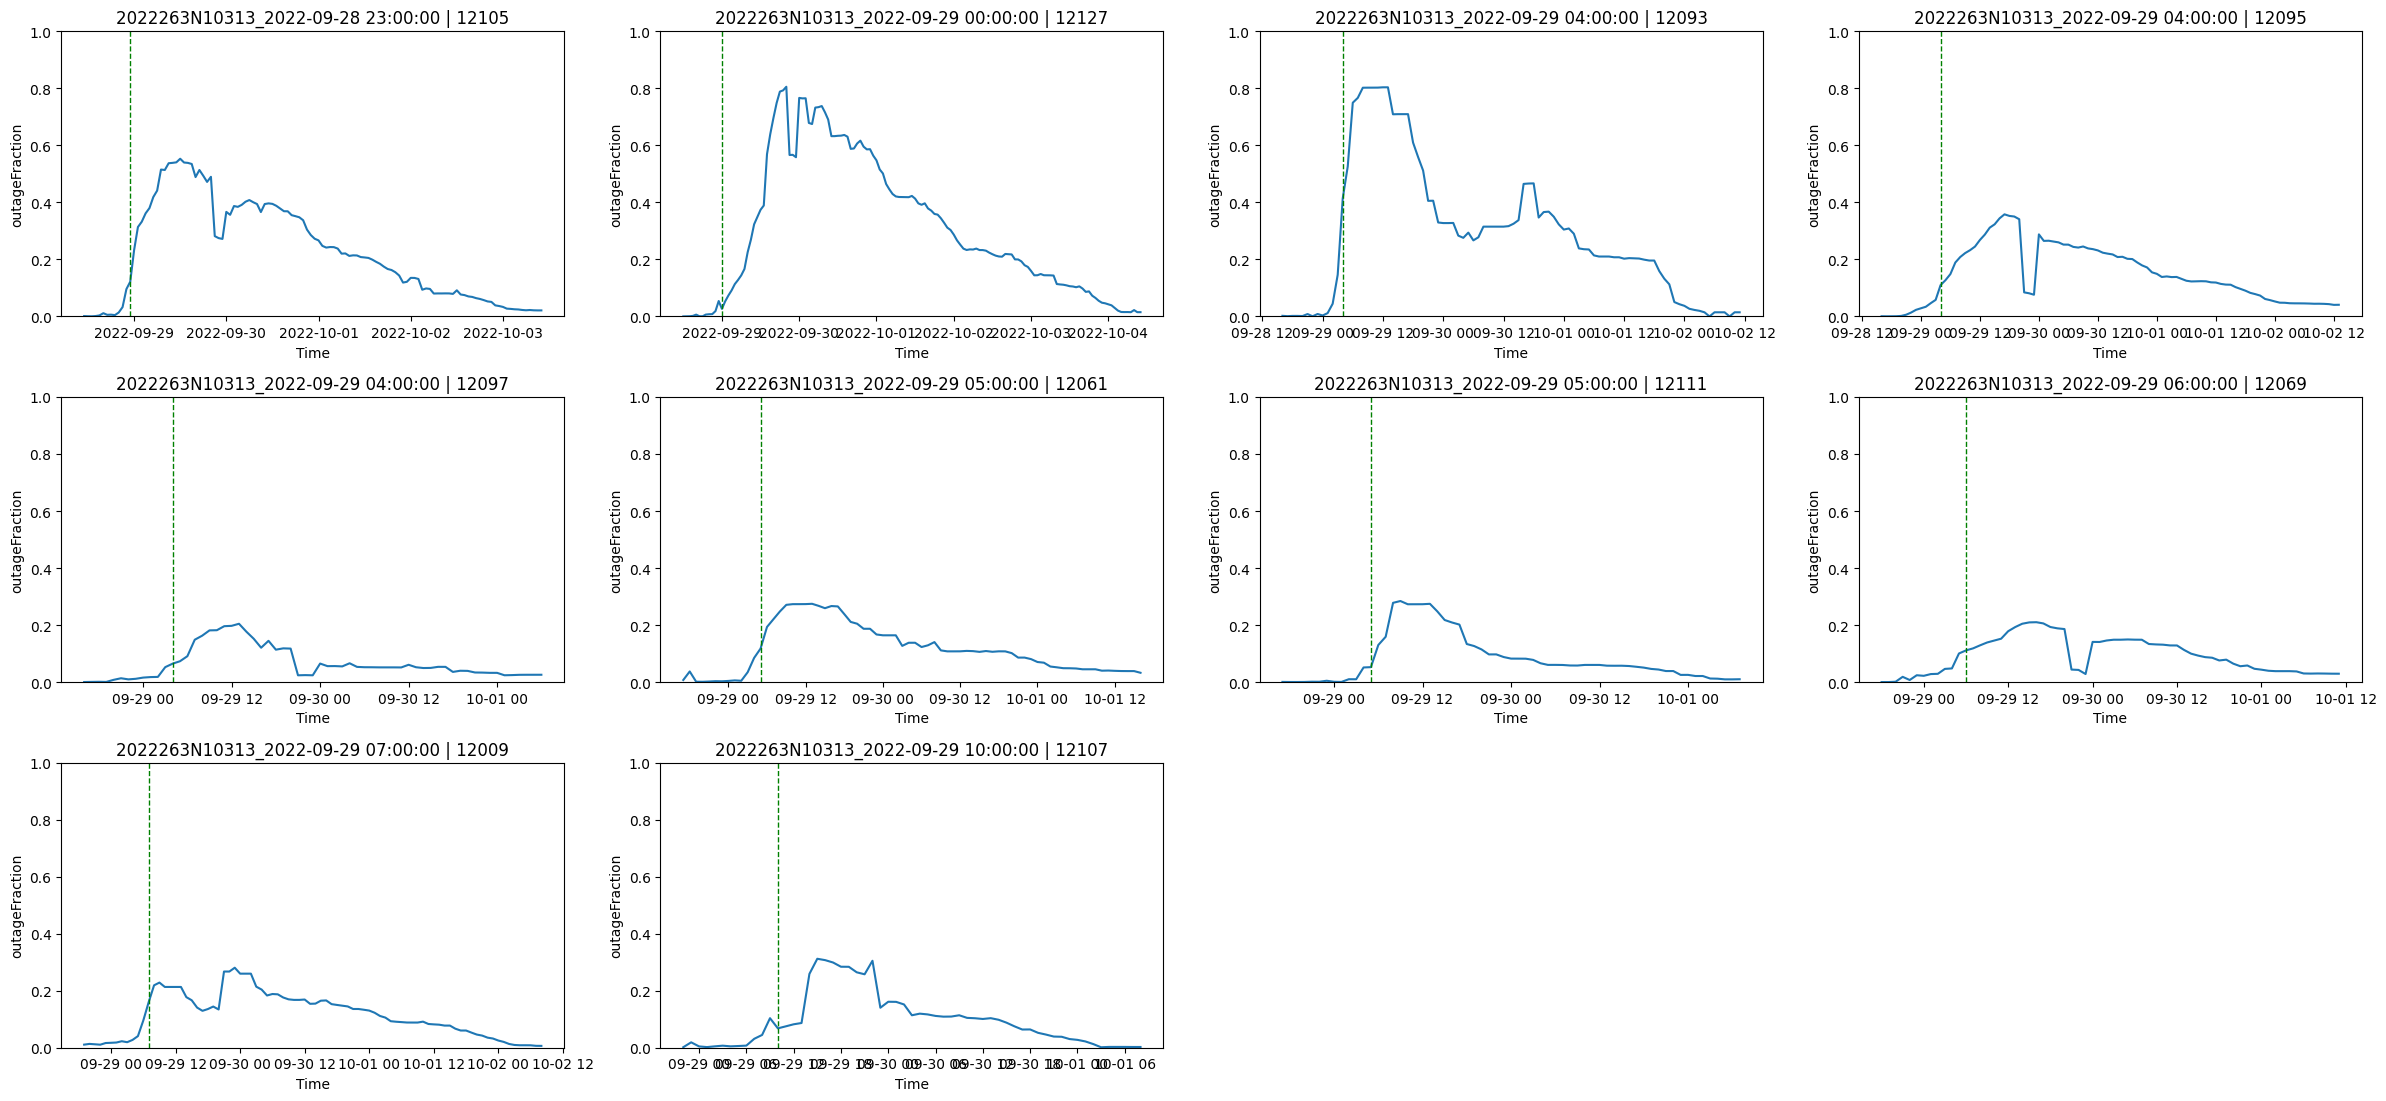

In [52]:
# CELL — Plot 20 events with event_start marked

import matplotlib.pyplot as plt

chunk = 5
plots_per_chunk = 20

groups = (
    df[["event_id", "CountyFIPS"]]
    .drop_duplicates()
    .sort_values(["event_id", "CountyFIPS"])
    .reset_index(drop=True)
)

start = (chunk - 1) * plots_per_chunk
end = start + plots_per_chunk

fig, axes = plt.subplots(5, 4, figsize=(24, 18))
axes = axes.ravel()

for ax in axes:
    ax.set_visible(False)

for ax, (_, row) in zip(axes, groups.iloc[start:end].iterrows()):
    event_id = row["event_id"]
    county_fips = row["CountyFIPS"]

    g = df[
        (df["event_id"] == event_id) &
        (df["CountyFIPS"] == county_fips)
    ].sort_values("datetime")

    event_start = g["event_start"].iloc[0]

    ax.set_visible(True)
    ax.plot(g["datetime"], g["outageFraction"], linewidth=1.5)

    # vertical line at event start
    ax.axvline(event_start, linestyle="--", linewidth=1, color='green')

    ax.set_title(f"{event_id} | {county_fips}")
    ax.set_xlabel("Time")
    ax.set_ylabel("outageFraction")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()